# Introduction
State notebook purpose here

### Imports
Import libraries and write settings here.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

In [2]:
df = pd.read_parquet('C:/Users/willk/Downloads/world_development_indicators_indicators_data.parquet')
subset = df[df['country_name'] == 'United States']
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7811291 entries, 0 to 7811290
Data columns (total 6 columns):
country_name      object
country_code      object
indicator_name    object
indicator_code    object
year              int64
value             float64
dtypes: float64(1), int64(1), object(4)
memory usage: 417.2+ MB


In [3]:
subset.groupby('indicator_name')['year'].count().sort_values()

indicator_name
2005 PPP conversion factor, GDP (LCU per international $)                                                                       1
Droughts, floods, extreme temperatures (% of population, average 1990-2009)                                                     1
Ease of doing business index (1=most business-friendly regulations)                                                             1
Annualized average growth rate in per capita real survey mean consumption or income, total population (%)                       1
Plant species (higher), threatened                                                                                              1
Bird species, threatened                                                                                                        1
Fish species, threatened                                                                                                        1
Battle-related deaths (number of people)                                   

In [4]:
to_plot = df[df['indicator_name'] == 'Primary education, duration (years)']
to_plot.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12226 entries, 384 to 7810510
Data columns (total 6 columns):
country_name      12226 non-null object
country_code      12226 non-null object
indicator_name    12226 non-null object
indicator_code    12226 non-null object
year              12226 non-null int64
value             12226 non-null float64
dtypes: float64(1), int64(1), object(4)
memory usage: 668.6+ KB


In [5]:
import plotly_express as px

In [7]:
to_plot.head()

,country_name,country_code,indicator_name,indicator_code,year,value
384,Uruguay,URY,"Primary education, duration (years)",SE.PRM.DURS,1989,6.0
522,St. Vincent and the Grenadines,VCT,"Primary education, duration (years)",SE.PRM.DURS,1975,7.0
1067,Iraq,IRQ,"Primary education, duration (years)",SE.PRM.DURS,1984,6.0
1246,St. Lucia,LCA,"Primary education, duration (years)",SE.PRM.DURS,1977,7.0
1980,San Marino,SMR,"Primary education, duration (years)",SE.PRM.DURS,1987,5.0


In [80]:
px.choropleth(to_plot[to_plot['year'].isin(range(2000, 2011))], title='Primary Education Duration',
              projection='robinson', color_continuous_scale=px.colors.sequential.Cividis,
              locations='country_code', color='value', animation_frame='year', animation_group='country_code')

In [83]:
to_plot.continent.unique()

array(['South America', 'Asia', 'Africa', 'North America', 'Europe',
       'Oceania'], dtype=object)

In [84]:
px.scatter(to_plot.query('continent == "Asia"'), x='year', y='value', title='Primary Education Duration in Asia')

In [85]:
df = df.merge(world[['continent', 'iso_a3', 'geometry']], left_on='country_code', right_on='iso_a3', how='left')
df = df.dropna(subset=['geometry'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5765960 entries, 1 to 7811290
Data columns (total 9 columns):
country_name      object
country_code      object
indicator_name    object
indicator_code    object
year              int64
value             float64
continent         object
iso_a3            object
geometry          object
dtypes: float64(1), int64(1), object(7)
memory usage: 439.9+ MB


In [87]:
# df = df.drop(columns=['iso_a3', 'indicator_code'])
df.drop(columns=['geometry']).to_parquet('C:/Users/willk/Downloads/world_development_indicators_data_clean.parquet')

In [94]:
df.columns

Index(['Unnamed: 0', 'country_name', 'country_code', 'year', 'continent',
       'Age dependency ratio (% of working-age population)',
       'Agricultural land (sq. km)',
       'Air transport, registered carrier departures worldwide',
       'Alternative and nuclear energy (% of total energy use)',
       'Birth rate, crude (per 1,000 people)', 'CO2 emissions (kt)',
       'CO2 emissions (metric tons per capita)',
       'Electricity production from nuclear sources (% of total)',
       'Fixed telephone subscriptions (per 100 people)',
       'Food imports (% of merchandise imports)',
       'Fossil fuel energy consumption (% of total)',
       'Fuel imports (% of merchandise imports)', 'GDP growth (annual %)',
       'GDP per capita (current US$)',
       'Government expenditure on education, total (% of GDP)',
       'Land area (sq. km)', 'Military expenditure (% of GDP)',
       'Mobile cellular subscriptions (per 100 people)',
       'Mortality rate, infant (per 1,000 live births

In [99]:
px.choropleth(df, locations='country_code', color='Urban population (% of total)')

In [103]:
df.columns

Index(['Unnamed: 0', 'country_name', 'country_code', 'year', 'continent',
       'Age dependency ratio (% of working-age population)',
       'Agricultural land (sq. km)',
       'Air transport, registered carrier departures worldwide',
       'Alternative and nuclear energy (% of total energy use)',
       'Birth rate, crude (per 1,000 people)', 'CO2 emissions (kt)',
       'CO2 emissions (metric tons per capita)',
       'Electricity production from nuclear sources (% of total)',
       'Fixed telephone subscriptions (per 100 people)',
       'Food imports (% of merchandise imports)',
       'Fossil fuel energy consumption (% of total)',
       'Fuel imports (% of merchandise imports)', 'GDP growth (annual %)',
       'GDP per capita (current US$)',
       'Government expenditure on education, total (% of GDP)',
       'Land area (sq. km)', 'Military expenditure (% of GDP)',
       'Mobile cellular subscriptions (per 100 people)',
       'Mortality rate, infant (per 1,000 live births

In [104]:
px.line(df.query('country_code == "USA"'), x='year', y='Military expenditure (% of GDP)')

In [106]:
px.line(df.query('continent == "North America"'), color='country_code', x='year', y='Military expenditure (% of GDP)')

In [107]:
px.line(df, color='country_code', x='year', y='Military expenditure (% of GDP)', facet_row='continent')

In [108]:
df.columns

Index(['Unnamed: 0', 'country_name', 'country_code', 'year', 'continent',
       'Age dependency ratio (% of working-age population)',
       'Agricultural land (sq. km)',
       'Air transport, registered carrier departures worldwide',
       'Alternative and nuclear energy (% of total energy use)',
       'Birth rate, crude (per 1,000 people)', 'CO2 emissions (kt)',
       'CO2 emissions (metric tons per capita)',
       'Electricity production from nuclear sources (% of total)',
       'Fixed telephone subscriptions (per 100 people)',
       'Food imports (% of merchandise imports)',
       'Fossil fuel energy consumption (% of total)',
       'Fuel imports (% of merchandise imports)', 'GDP growth (annual %)',
       'GDP per capita (current US$)',
       'Government expenditure on education, total (% of GDP)',
       'Land area (sq. km)', 'Military expenditure (% of GDP)',
       'Mobile cellular subscriptions (per 100 people)',
       'Mortality rate, infant (per 1,000 live births

In [115]:
px.violin(df.query('year == 2010'),
                    y='GDP per capita (current US$)', animation_frame='year', 
          animation_group='country_code')

In [119]:
df.columns

Index(['Unnamed: 0', 'country_name', 'country_code', 'year', 'continent',
       'Age dependency ratio (% of working-age population)',
       'Agricultural land (sq. km)',
       'Air transport, registered carrier departures worldwide',
       'Alternative and nuclear energy (% of total energy use)',
       'Birth rate, crude (per 1,000 people)', 'CO2 emissions (kt)',
       'CO2 emissions (metric tons per capita)',
       'Electricity production from nuclear sources (% of total)',
       'Fixed telephone subscriptions (per 100 people)',
       'Food imports (% of merchandise imports)',
       'Fossil fuel energy consumption (% of total)',
       'Fuel imports (% of merchandise imports)', 'GDP growth (annual %)',
       'GDP per capita (current US$)',
       'Government expenditure on education, total (% of GDP)',
       'Land area (sq. km)', 'Military expenditure (% of GDP)',
       'Mobile cellular subscriptions (per 100 people)',
       'Mortality rate, infant (per 1,000 live births

In [122]:
px.scatter(df.query('year == 2016'), x = 'GDP per capita (current US$)', y='Fixed telephone subscriptions (per 100 people)')

In [125]:
px.scatter(df.query('year == 2016'), x = 'GDP per capita (current US$)', y='Urban population (% of total)',
          hover_name='country_name', title='Urban Population vs GDP')

In [126]:
fe = pd.read_csv('../../sample_fishing_effort.csv', parse_dates=['date'])
fe.head()

,date,lat_bin,lon_bin,flag,geartype,vessel_hours,fishing_hours,mmsi_present,latitude,longitude,x,y],y
0,2012-02-20,-5376,-6191,ARG,trawlers,3.072083,0.000000,1,-53.76,-61.91,-6.891790e+06,-7.124834e+06,-7.124834e+06
1,2012-02-20,-5375,-6219,ARG,trawlers,2.298889,0.000000,1,-53.75,-62.19,-6.922959e+06,-7.122951e+06,-7.122951e+06
2,2012-02-20,-4863,-6517,ARG,trawlers,3.758194,3.758194,1,-48.63,-65.17,-7.254691e+06,-6.212312e+06,-6.212312e+06
3,2012-02-20,-4863,-6474,ARG,trawlers,0.775139,0.000000,1,-48.63,-64.74,-7.206824e+06,-6.212312e+06,-6.212312e+06
4,2012-02-20,-4863,-6475,ARG,trawlers,2.298472,0.000000,1,-48.63,-64.75,-7.207937e+06,-6.212312e+06,-6.212312e+06


In [127]:
px.scatter_geo(fe, lat='latitude', lon='longitude', size='fishing_hours')

In [ ]:
px.scatter_geo(fe, lat='latitude', lon='longitude', size='fishing_hours', animation_frame='date')

In [121]:
px.density_contour(df.query('year == 2016'), x='Fixed telephone subscriptions (per 100 people)',  y='Mobile cellular subscriptions (per 100 people)')

In [114]:
px.violin(df.query('year == 2010'),
                   x='continent', y='GDP per capita (current US$)', animation_frame='year', 
          animation_group='country_code')

In [102]:
df.query('year == 2018')

,Unnamed: 0,country_name,country_code,year,continent,Age dependency ratio (% of working-age population),Agricultural land (sq. km),"Air transport, registered carrier departures worldwide",Alternative and nuclear energy (% of total energy use),"Birth rate, crude (per 1,000 people)",...,Military expenditure (% of GDP),Mobile cellular subscriptions (per 100 people),"Mortality rate, infant (per 1,000 live births)",Population density (people per sq. km of land area),Population in largest city,"Primary education, duration (years)","Services, value added (% of GDP)",Total fisheries production (metric tons),Trade (% of GDP),Urban population (% of total)
48,48,Afghanistan,AFG,2018,Asia,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.0,NaN,NaN,NaN,NaN
97,97,Albania,ALB,2018,Europe,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN
146,146,Algeria,DZA,2018,Africa,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN
195,195,Angola,AGO,2018,Africa,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.0,NaN,NaN,NaN,NaN
244,244,Argentina,ARG,2018,South America,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.0,NaN,NaN,NaN,NaN
293,293,Armenia,ARM,2018,Asia,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
342,342,Australia,AUS,2018,Oceania,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN
391,391,Austria,AUT,2018,Europe,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
440,440,Azerbaijan,AZE,2018,Asia,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
489,489,"Bahamas, The",BHS,2018,North America,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.0,NaN,NaN,NaN,NaN


In [101]:
df.query('country_code == "USA"')

,Unnamed: 0,country_name,country_code,year,continent,Age dependency ratio (% of working-age population),Agricultural land (sq. km),"Air transport, registered carrier departures worldwide",Alternative and nuclear energy (% of total energy use),"Birth rate, crude (per 1,000 people)",...,Military expenditure (% of GDP),Mobile cellular subscriptions (per 100 people),"Mortality rate, infant (per 1,000 live births)",Population density (people per sq. km of land area),Population in largest city,"Primary education, duration (years)","Services, value added (% of GDP)",Total fisheries production (metric tons),Trade (% of GDP),Urban population (% of total)
7791,7791,United States,USA,1970,North America,61.754868,4.344000e+06,5099200.0,1.810684,18.4,...,7.689700,0.000000,19.9,22.388131,16191180.0,6.0,NaN,2962979.0,10.732570,73.602
7792,7792,United States,USA,1971,North America,60.517814,4.333000e+06,4999200.0,2.124913,17.2,...,6.643475,NaN,19.1,22.672989,16128515.0,6.0,NaN,3050820.0,10.730366,73.613
7793,7793,United States,USA,1972,North America,59.300442,4.323000e+06,4985200.0,2.382324,15.6,...,6.271831,NaN,18.3,22.917012,16066007.0,6.0,NaN,2946225.0,11.311171,73.623
7794,7794,United States,USA,1973,North America,58.089994,4.312000e+06,5058200.0,2.784347,14.8,...,5.668750,NaN,17.5,23.136797,16003912.0,6.0,NaN,2978682.0,13.050235,73.633
7795,7795,United States,USA,1974,North America,56.865256,4.301580e+06,4650400.0,3.546220,14.8,...,5.729167,NaN,16.7,23.349158,15941972.0,6.0,NaN,3053006.0,16.407018,73.643
7796,7796,United States,USA,1975,North America,55.629392,4.301580e+06,4576100.0,4.646529,14.6,...,5.397913,0.000000,15.9,23.580516,15880271.0,6.0,NaN,3065741.0,15.479451,73.653
7797,7797,United States,USA,1976,North America,54.912625,4.301580e+06,4690500.0,4.569871,14.6,...,4.988162,0.000000,15.2,23.805650,15818725.0,6.0,NaN,3272174.0,16.013159,73.663
7798,7798,United States,USA,1977,North America,54.115517,4.303310e+06,4795900.0,5.025204,15.1,...,4.971381,0.000000,14.5,24.046289,15757586.0,6.0,NaN,3211927.0,16.385476,73.673
7799,7799,United States,USA,1978,North America,53.324021,4.281630e+06,4857000.0,5.505754,15.0,...,4.762812,0.000000,13.8,24.302432,15696599.0,6.0,NaN,3636483.0,16.937151,73.682
7800,7800,United States,USA,1979,North America,52.636219,4.281630e+06,5041800.0,5.246082,15.6,...,4.772422,0.000000,13.2,24.572113,15635849.0,6.0,NaN,3722375.0,18.342620,73.692


In [98]:
px.histogram(df, x='Electricity production from nuclear sources (% of total)', histfunc='sum')

In [93]:
px.scatter(df, x = 'CO2 emissions (kt)', 
           y='Birth rate, crude (per 1,000 people)', animation_frame='year', animation_group='country_name',
          color='continent')

In [89]:
df = pd.read_csv('C:/Users/willk/Downloads/world_development_indicators_data_subset.csv')
df.corr()

,Unnamed: 0,year,Age dependency ratio (% of working-age population),Agricultural land (sq. km),"Air transport, registered carrier departures worldwide",Alternative and nuclear energy (% of total energy use),"Birth rate, crude (per 1,000 people)",CO2 emissions (kt),CO2 emissions (metric tons per capita),Electricity production from nuclear sources (% of total),...,Military expenditure (% of GDP),Mobile cellular subscriptions (per 100 people),"Mortality rate, infant (per 1,000 live births)",Population density (people per sq. km of land area),Population in largest city,"Primary education, duration (years)","Services, value added (% of GDP)",Total fisheries production (metric tons),Trade (% of GDP),Urban population (% of total)
Unnamed: 0,1.000000,0.005916,0.026931,-0.069031,0.109924,0.050066,0.028297,0.060444,0.082824,0.014626,...,0.075782,0.030054,-0.033427,0.017900,-0.031157,0.044999,0.012652,-0.032014,0.007611,-0.069800
year,0.005916,1.000000,-0.350757,0.006304,0.076412,0.117955,-0.341895,0.061859,-0.001704,0.122309,...,-0.193412,0.740090,-0.420551,0.158986,0.178600,0.055652,0.273290,0.068332,0.267827,0.228648
Age dependency ratio (% of working-age population),0.026931,-0.350757,1.000000,-0.119225,-0.168818,-0.271547,0.927786,-0.225399,-0.490912,-0.333880,...,0.108772,-0.473233,0.760158,-0.211189,-0.246466,0.297021,-0.448962,-0.175375,-0.223268,-0.661811
Agricultural land (sq. km),-0.069031,0.006304,-0.119225,1.000000,0.530593,-0.082392,-0.102096,0.680126,0.121422,-0.012136,...,0.010049,0.012512,-0.058178,-0.102016,0.428503,-0.062795,0.062989,0.472366,-0.280450,0.094936
"Air transport, registered carrier departures worldwide",0.109924,0.076412,-0.168818,0.530593,1.000000,0.070368,-0.180768,0.800656,0.213718,0.148347,...,0.015356,0.107626,-0.155407,0.007449,0.409095,0.020718,0.224247,0.274217,-0.138819,0.169671
Alternative and nuclear energy (% of total energy use),0.050066,0.117955,-0.271547,-0.082392,0.070368,1.000000,-0.355851,0.011239,-0.007460,0.591878,...,-0.171672,0.150892,-0.319257,-0.066091,0.024699,-0.080154,0.254057,0.009167,0.051039,0.290535
"Birth rate, crude (per 1,000 people)",0.028297,-0.341895,0.927786,-0.102096,-0.180768,-0.355851,1.000000,-0.218893,-0.402746,-0.397841,...,0.126912,-0.428327,0.864637,-0.232693,-0.257099,0.301662,-0.523679,-0.151914,-0.221568,-0.700923
CO2 emissions (kt),0.060444,0.061859,-0.225399,0.680126,0.800656,0.011239,-0.218893,1.000000,0.172667,0.119885,...,0.011386,0.081189,-0.166859,0.065599,0.525078,-0.037220,0.135453,0.713441,-0.173028,0.134369
CO2 emissions (metric tons per capita),0.082824,-0.001704,-0.490912,0.121422,0.213718,-0.007460,-0.402746,0.172667,1.000000,0.105516,...,0.097016,0.223590,-0.417976,0.007116,0.063225,-0.019017,0.228662,0.019432,0.218325,0.543536
Electricity production from nuclear sources (% of total),0.014626,0.122309,-0.333880,-0.012136,0.148347,0.591878,-0.397841,0.119885,0.105516,1.000000,...,-0.090144,0.144593,-0.311733,0.123596,0.134690,-0.198493,0.261894,0.011739,0.083817,0.291741


In [17]:
import geopandas
world = geopandas.read_file(geopandas.datasets.get_path('naturalearth_lowres'))
world.head()

,pop_est,continent,name,iso_a3,gdp_md_est,geometry
0,28400000.0,Asia,Afghanistan,AFG,22270.0,"POLYGON ((61.21081709172574 35.65007233330923,..."
1,12799293.0,Africa,Angola,AGO,110300.0,(POLYGON ((16.32652835456705 -5.87747039146621...
2,3639453.0,Europe,Albania,ALB,21810.0,"POLYGON ((20.59024743010491 41.85540416113361,..."
3,4798491.0,Asia,United Arab Emirates,ARE,184300.0,"POLYGON ((51.57951867046327 24.24549713795111,..."
4,40913584.0,South America,Argentina,ARG,573900.0,(POLYGON ((-65.50000000000003 -55.199999999999...


In [20]:
world.tail(10)

,pop_est,continent,name,iso_a3,gdp_md_est,geometry
167,3494382.0,South America,Uruguay,URY,43160.0,POLYGON ((-57.62513342958296 -30.2162948544542...
168,313973000.0,North America,United States,USA,15094000.0,"(POLYGON ((-155.54211 19.08348000000001, -155...."
169,27606007.0,Asia,Uzbekistan,UZB,71670.0,"POLYGON ((66.51860680528867 37.36278432875879,..."
170,26814843.0,South America,Venezuela,VEN,357400.0,"POLYGON ((-71.3315836249503 11.77628408451581,..."
171,86967524.0,Asia,Vietnam,VNM,241700.0,"POLYGON ((108.0501802917829 21.55237986906012,..."
172,218519.0,Oceania,Vanuatu,VUT,988.5,(POLYGON ((167.8448767438451 -16.4663331030971...
173,23822783.0,Asia,Yemen,YEM,55280.0,"POLYGON ((53.10857262554751 16.65105113368895,..."
174,49052489.0,Africa,South Africa,ZAF,491000.0,POLYGON ((31.52100141777888 -29.25738697684626...
175,11862740.0,Africa,Zambia,ZMB,17500.0,"POLYGON ((32.75937544122132 -9.23059905358906,..."
176,12619600.0,Africa,Zimbabwe,ZWE,9323.0,"POLYGON ((31.19140913262129 -22.2515096981724,..."


In [23]:
import geoviews as gv
import geoviews.feature as gf
gdata = gv.Dataset(to_plot, kdims=['geometry', 'year'], vdims=['value'])


In [27]:
to_plot = to_plot.dropna(subset=['geometry'])

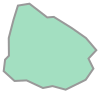

In [26]:
to_plot['geometry'].iloc[0]

In [30]:
gv.Polygons(world)

:Polygons   [Longitude,Latitude]

In [32]:
to_plot.head()

,country_name,country_code,indicator_name,indicator_code,year,value,iso_a3,geometry,continent
0,Uruguay,URY,"Primary education, duration (years)",SE.PRM.DURS,1989,6.0,URY,POLYGON ((-57.62513342958296 -30.2162948544542...,South America
2,Iraq,IRQ,"Primary education, duration (years)",SE.PRM.DURS,1984,6.0,IRQ,"POLYGON ((45.42061811705321 35.97754588474282,...",Asia
6,Kazakhstan,KAZ,"Primary education, duration (years)",SE.PRM.DURS,2004,4.0,KAZ,"POLYGON ((70.96231489449929 42.26615428320554,...",Asia
7,Timor-Leste,TLS,"Primary education, duration (years)",SE.PRM.DURS,2002,6.0,TLS,POLYGON ((124.9686824891162 -8.892790215697083...,Asia
8,Mozambique,MOZ,"Primary education, duration (years)",SE.PRM.DURS,2016,7.0,MOZ,POLYGON ((34.55998904799935 -11.52002003341592...,Africa


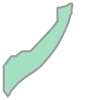

In [34]:
to_plot['geometry'].iloc[10]

In [18]:
to_plot = to_plot.merge(world[['iso_a3', 'geometry', 'continent']], left_on='country_code', right_on='iso_a3', how='left')
to_plot.head()

,country_name,country_code,indicator_name,indicator_code,year,value,iso_a3,geometry,continent
0,Uruguay,URY,"Primary education, duration (years)",SE.PRM.DURS,1989,6.0,URY,POLYGON ((-57.62513342958296 -30.2162948544542...,South America
1,St. Vincent and the Grenadines,VCT,"Primary education, duration (years)",SE.PRM.DURS,1975,7.0,NaN,NaN,NaN
2,Iraq,IRQ,"Primary education, duration (years)",SE.PRM.DURS,1984,6.0,IRQ,"POLYGON ((45.42061811705321 35.97754588474282,...",Asia
3,St. Lucia,LCA,"Primary education, duration (years)",SE.PRM.DURS,1977,7.0,NaN,NaN,NaN
4,San Marino,SMR,"Primary education, duration (years)",SE.PRM.DURS,1987,5.0,NaN,NaN,NaN


In [68]:
type(world)

geopandas.geodataframe.GeoDataFrame

In [73]:
import geopandas

geodata = geopandas.GeoDataFrame(to_plot.query('year == 2010'))

In [79]:
gv.Polygons(geodata, vdims=['value']).opts(tools=['hover'], width=800, height=550)

:Polygons   [Longitude,Latitude]   (value)

In [45]:
try_ = to_plot[['value', 'country_name', 'country_code', 'geometry']]
try_.isna().sum()

value           0
country_name    0
country_code    0
geometry        0
dtype: int64

In [41]:
world.columns

Index(['pop_est', 'continent', 'name', 'iso_a3', 'gdp_md_est', 'geometry'], dtype='object')

In [40]:
p = gv.Polygons(world)
p

:Polygons   [Longitude,Latitude]

In [42]:
try_.columns

Index(['value', 'geometry'], dtype='object')

In [43]:
try_.dtypes

value       float64
geometry     object
dtype: object

In [44]:
world.dtypes

pop_est       float64
continent      object
name           object
iso_a3         object
gdp_md_est    float64
geometry       object
dtype: object

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
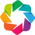

In [52]:
import holoviews as hv
hv.extension('bokeh', 'matplotlib')

In [53]:
polys = gv.Polygons(world, vdims=['gdp_md_est', 'continent', 'name'])
polys.opts(width=600, height=500, tools=['hover'], backend='bokeh', cmap='viridis', ylim=(-60, 90))

:Polygons   [Longitude,Latitude]   (gdp_md_est,continent,name)

In [56]:
try_.columns = ['value', 'name', 'iso_a3', 'geometry']

In [60]:
try_.iloc[10]

value                                                       6
name                                                  Somalia
iso_a3                                                    SOM
geometry    POLYGON ((49.72862 11.5789, 50.25878000000001 ...
Name: 18, dtype: object

In [66]:
try_.iloc[:2]

,value,name,iso_a3,geometry
0,6.0,Uruguay,URY,POLYGON ((-57.62513342958296 -30.2162948544542...
2,6.0,Iraq,IRQ,"POLYGON ((45.42061811705321 35.97754588474282,..."


In [67]:
gv.Polygons(try_.iloc[:2], vdims=['value'])

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

:Polygons   [name,iso_a3]   (value)

In [55]:
world.head()

,pop_est,continent,name,iso_a3,gdp_md_est,geometry
0,28400000.0,Asia,Afghanistan,AFG,22270.0,"POLYGON ((61.21081709172574 35.65007233330923,..."
1,12799293.0,Africa,Angola,AGO,110300.0,(POLYGON ((16.32652835456705 -5.87747039146621...
2,3639453.0,Europe,Albania,ALB,21810.0,"POLYGON ((20.59024743010491 41.85540416113361,..."
3,4798491.0,Asia,United Arab Emirates,ARE,184300.0,"POLYGON ((51.57951867046327 24.24549713795111,..."
4,40913584.0,South America,Argentina,ARG,573900.0,(POLYGON ((-65.50000000000003 -55.199999999999...


In [49]:
gv.Polygons(try_, vdims=['country_code', 'country_name', 'value'])

ValueError: kdims: list length must be between 2 and 2 (inclusive)

In [36]:
px.scatter(to_plot, x='year', y='value', color='continent')

In [ ]:
import geoviews as gv
import geoviews.feature as gf
gdata = gv.Dataset(to_plot, kdims=['country_code', 'year'], vdims=['value'])
gdata.to(gv.Polygons) * gf.coastline

In [ ]:
gdata

In [ ]:
subset.head()

In [ ]:
import plotly_express as px
subset.head()

In [ ]:


# Options for pandas
pd.options.display.max_columns = 50
pd.options.display.max_rows = 30

# Display all cell outputs
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

from IPython import get_ipython
ipython = get_ipython()

# autoreload extension
if 'autoreload' not in ipython.extension_manager.loaded:
    %load_ext autoreload

%autoreload 2

# Visualizations
import plotly.plotly as py
import plotly.graph_objs as go
from plotly.offline import iplot, init_notebook_mode
init_notebook_mode(connected=True)

import cufflinks as cf
cf.go_offline(connected=True)
cf.set_config_file(theme='white')

# Analysis/Modeling
Do work here

# Results
Show graphs and stats here

# Conclusions and Next Steps
Summarize findings here